In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [146]:
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [147]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [148]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [149]:
df = pd.read_csv("../data/Customer-churn-details.csv")

In [150]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [151]:
df.shape

(7043, 21)

# DATA CLEANING

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [153]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [154]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [155]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [156]:
df = df.drop("customerID", axis=1)

# EDA

In [157]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


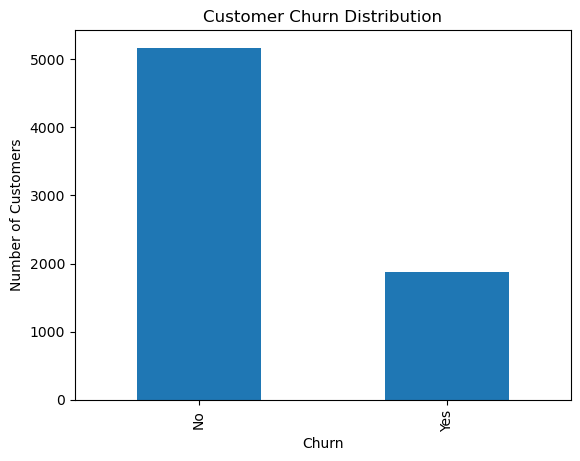

In [158]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

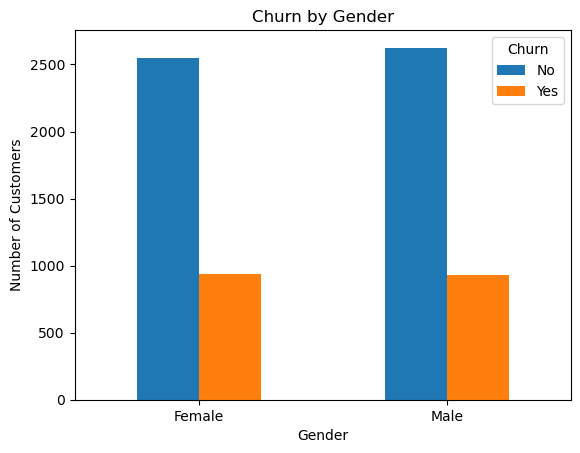

In [159]:
pd.crosstab(
    df["gender"],
    df["Churn"]
).plot(kind="bar")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

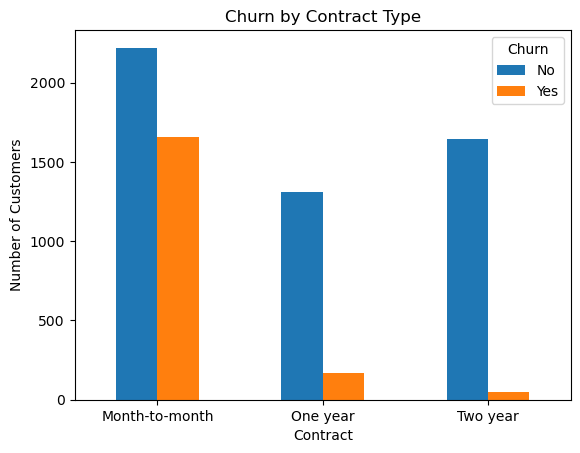

In [160]:
pd.crosstab(
    df["Contract"],
    df["Churn"]
).plot(kind="bar")

plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

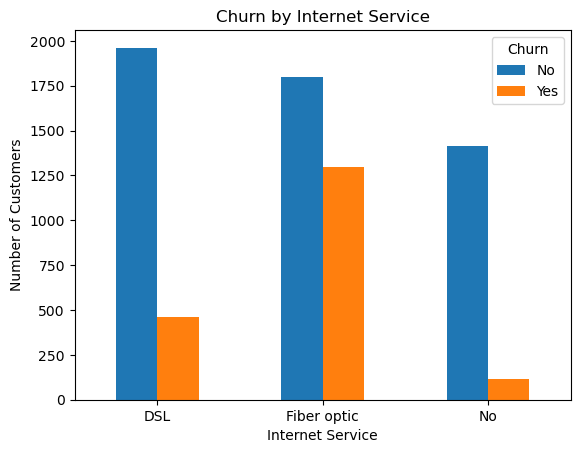

In [161]:
pd.crosstab(
    df["InternetService"],
    df["Churn"]
).plot(kind="bar")

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

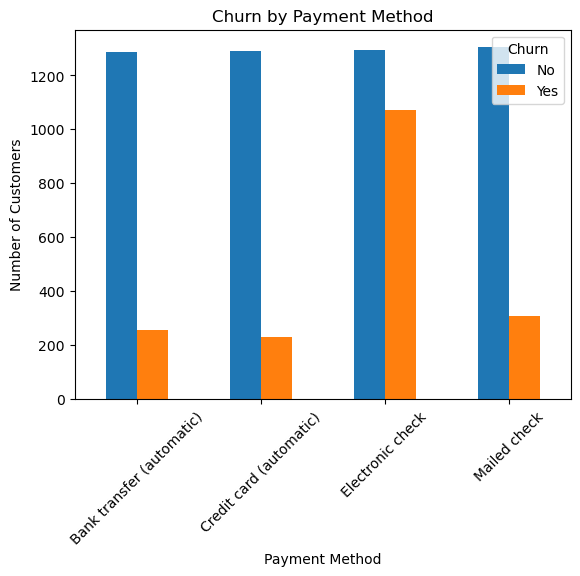

In [162]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
).plot(kind="bar")

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

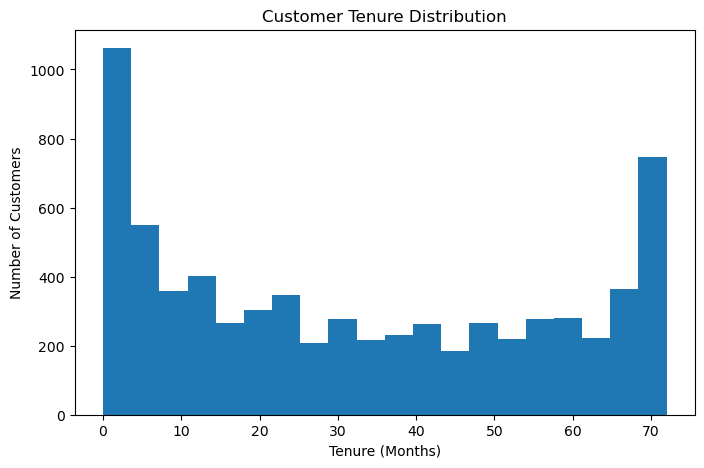

In [163]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=20)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

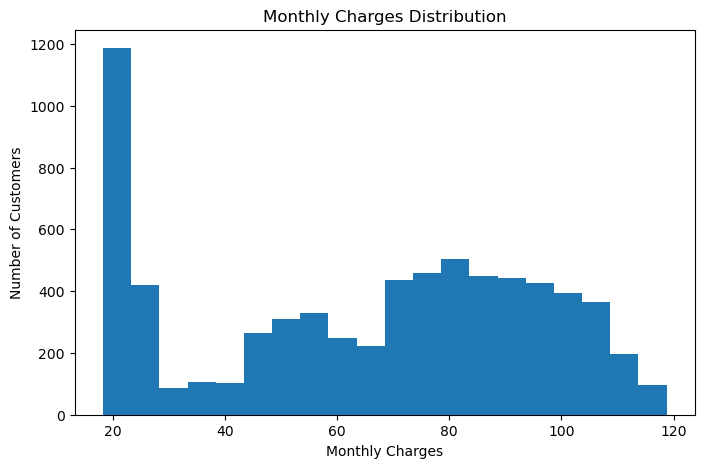

In [164]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

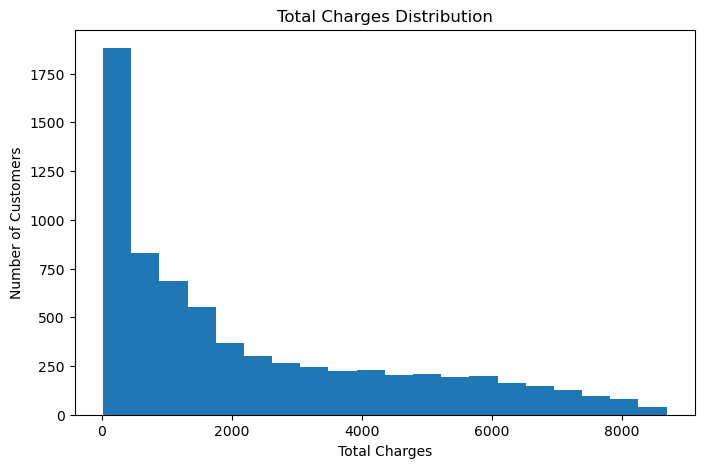

In [165]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalCharges"], bins=20)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

# Trainning

In [166]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [167]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [168]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [169]:
X = pd.get_dummies(X, drop_first=True)

In [170]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [172]:
scaler = StandardScaler()

In [173]:
X_train_scaled = scaler.fit_transform(X_train)

In [174]:
X_test_scaled = scaler.transform(X_test)

# LOGISTIC REGRESSION

In [175]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [176]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [177]:
logistic_pred = logistic_model.predict(X_test_scaled)

In [178]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall:", recall_score(y_test, logistic_pred))
print("F1 Score:", f1_score(y_test, logistic_pred))

Logistic Regression
Accuracy: 0.7388218594748048
Precision: 0.5051903114186851
Recall: 0.7807486631016043
F1 Score: 0.6134453781512605


In [179]:
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [180]:
logistic_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, logistic_probability)
)

ROC-AUC: 0.8412333049161694


# KNN

In [181]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [182]:
knn_model.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

In [183]:
knn_pred = knn_model.predict(
    X_test_scaled
)

In [184]:
print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred))
print("Recall:", recall_score(y_test, knn_pred))
print("F1 Score:", f1_score(y_test, knn_pred))

KNN
Accuracy: 0.7473385379701917
Precision: 0.5252808988764045
Recall: 0.5
F1 Score: 0.5123287671232877


In [185]:
knn_probability = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, knn_probability)
)

ROC-AUC: 0.7717972564519879


# SVM

In [186]:
svm_model = SVC(
    probability=True,
    class_weight="balanced"
)

In [187]:
svm_model.fit(
    X_train_scaled,
    y_train
)

SVC(class_weight='balanced', probability=True)

In [188]:
svm_pred = svm_model.predict(
    X_test_scaled
)

In [189]:
print("SVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))

SVM
Accuracy: 0.7473385379701917
Precision: 0.5161870503597122
Recall: 0.767379679144385
F1 Score: 0.6172043010752688


In [190]:
svm_probability = svm_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, svm_probability)
)

ROC-AUC: 0.8184789067142009


# DECISION TREE

In [191]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

In [192]:
tree_model.fit(
    X_train_scaled,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [193]:
tree_pred = tree_model.predict(
    X_test_scaled
)

In [194]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print("Precision:", precision_score(y_test, tree_pred))
print("Recall:", recall_score(y_test, tree_pred))
print("F1 Score:", f1_score(y_test, tree_pred))

Decision Tree
Accuracy: 0.7345635202271115
Precision: 0.5
Recall: 0.8074866310160428
F1 Score: 0.6175869120654397


In [195]:
tree_probability = tree_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, tree_probability)
)

ROC-AUC: 0.8307538298586893


# NAIVE BAYES

In [196]:
nb_model = GaussianNB()

In [197]:
nb_model.fit(
    X_train_scaled,
    y_train
)

GaussianNB()

In [198]:
nb_pred = nb_model.predict(
    X_test_scaled
)

In [199]:
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))

Naive Bayes
Accuracy: 0.6557842441447835
Precision: 0.4268774703557312
Recall: 0.8663101604278075
F1 Score: 0.5719329214474845


In [200]:
nb_probability = nb_model.predict_proba(
    X_test_scaled
)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, nb_probability)
)

ROC-AUC: 0.8092536619390841


In [201]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Decision Tree",
        "Naive Bayes"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, nb_pred)
    ],
    
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, nb_pred)
    ],
    
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, nb_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, nb_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_probability),
        roc_auc_score(y_test, knn_probability),
        roc_auc_score(y_test, svm_probability),
        roc_auc_score(y_test, tree_probability),
        roc_auc_score(y_test, nb_probability)
    ]
})

In [202]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.738822,0.505190,0.780749,0.613445,0.841233
1,KNN,0.747339,0.525281,0.500000,0.512329,0.771797
2,SVM,0.747339,0.516187,0.767380,0.617204,0.818479
3,Decision Tree,0.734564,0.500000,0.807487,0.617587,0.830754
4,Naive Bayes,0.655784,0.426877,0.866310,0.571933,0.809254


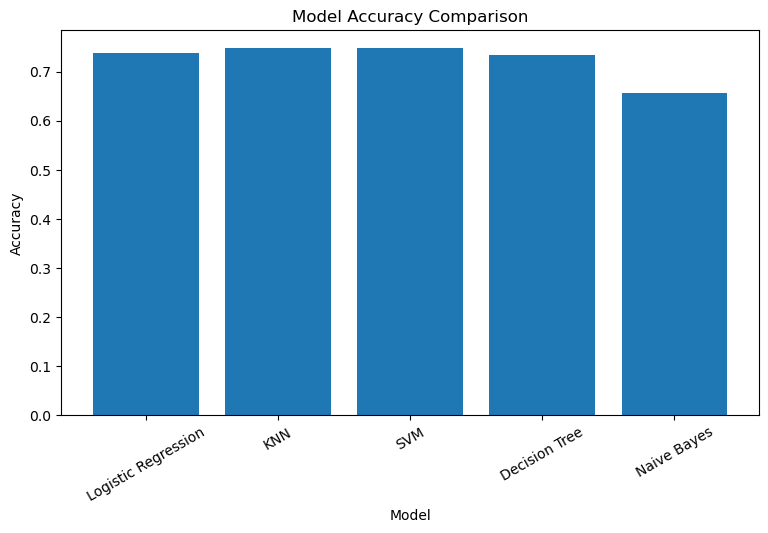

In [203]:
plt.figure(figsize=(9,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

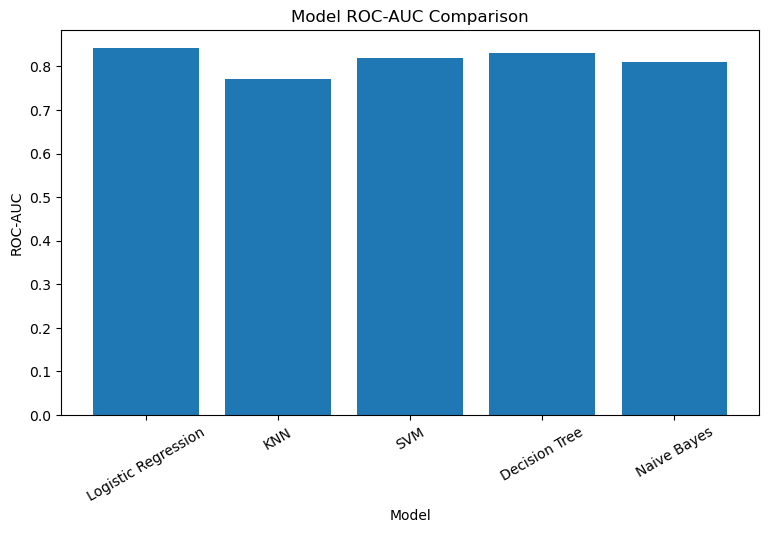

In [204]:
plt.figure(figsize=(9,5))

plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=30)

plt.show()

In [205]:
cm = confusion_matrix(
    y_test,
    logistic_pred
)

print(cm)

[[749 286]
 [ 82 292]]


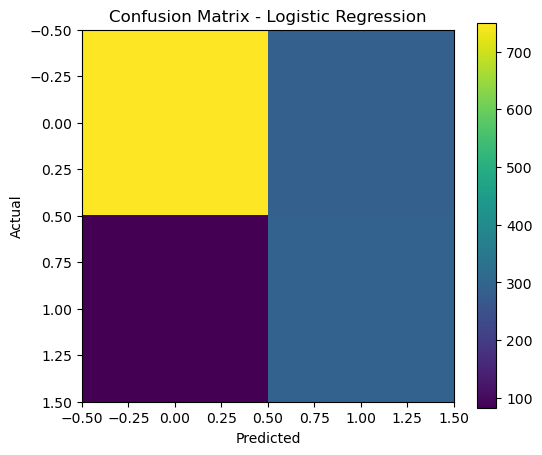

In [206]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [207]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]


# Categorical columns
categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [208]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [209]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [210]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [211]:
logistic_pipeline.fit(X_train, y_train)





ValueError: A given column is not a column of the dataframe